<a href="https://colab.research.google.com/github/ryaneliezer824-pixel/bio2110-project-Ryan-E/blob/main/notebooks/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Section 1: Import Libraries

In [1]:
# Imported requried libraries for data analysis and visualization
import pandas as pd
import matplotlib.pyplot as plt



Section 2: Upload and Load Dataset

In [3]:
# Upload DGIdb dataset file
from google.colab import files
uploaded = files.upload()

# Load the dataset into the pandas DataFrame
df = pd.read_csv("interactions.tsv", sep="\t")

# Display first few rows to confirm it loaded correctly
df.head()

Saving interactions.tsv to interactions.tsv


,gene_claim_name,gene_concept_id,gene_name,interaction_source_db_name,interaction_source_db_version,interaction_type,interaction_score,drug_claim_name,drug_concept_id,drug_name,approved,immunotherapy,anti_neoplastic
0,CYP2D6,hgnc:2625,CYP2D6,DTC,9/2/20,NaN,0.017709,RACLOPRIDE,ncit:C152139,RACLOPRIDE,False,False,False
1,PPARG,hgnc:9236,PPARG,DTC,9/2/20,NaN,0.840123,KALOPANAX-SAPONIN F,chembl:CHEMBL1833984,CHEMBL:CHEMBL1833984,False,False,False
2,ATAD5,hgnc:25752,ATAD5,DTC,9/2/20,NaN,0.177992,RO-5-3335,chembl:CHEMBL91609,CHEMBL:CHEMBL91609,False,False,False
3,RGS4,hgnc:10000,RGS4,DTC,9/2/20,NaN,0.034319,"3,4-DICHLOROISOCOUMARIN",drugbank:DB04459,"3,4-DICHLOROISOCOUMARIN",False,False,False
4,MAPK1,hgnc:6871,MAPK1,DTC,9/2/20,NaN,0.050007,WITHAFERIN A,iuphar.ligand:13097,WITHAFERIN A,False,False,False


Section 3: Explore the Dataset

In [4]:
# View columns and data size
df.columns
df.shape

(98239, 13)

Section 4: Filter for Cancer Drugs

In [5]:
# Filter dataset to only include cancer-related drugs
cancer_df = df[df["anti_neoplastic"] == True]

# Display a few row to chcek the flitered dataset
cancer_df.head()

,gene_claim_name,gene_concept_id,gene_name,interaction_source_db_name,interaction_source_db_version,interaction_type,interaction_score,drug_claim_name,drug_concept_id,drug_name,approved,immunotherapy,anti_neoplastic
6,VASCULAR ENDOTHELIAL GROWTH FACTOR RECEPTOR 2,hgnc:6307,KDR,TTD,2020.06.01,NaN,0.026412,HKI-272,rxcui:1940643,NERATINIB,True,False,True
12,KIT,hgnc:6342,KIT,DoCM,10-Apr-24,NaN,1.029066,IMATINIB,rxcui:282388,IMATINIB,True,False,True
18,CSNK2A3,hgnc:2458,CSNK2A3,PharmGKB,4/5/24,NaN,0.724244,cisplatin,rxcui:2555,CISPLATIN,True,False,True
23,UNIPROT:P22607,hgnc:3690,FGFR3,TdgClinicalTrial,Jan-14,NaN,0.154759,NINTEDANIB,rxcui:1592736,NINTEDANIB ESYLATE,True,False,True
28,ESR1,hgnc:3467,ESR1,ClearityFoundationClinicalTrial,15-Jun-13,inhibitor,0.056622,TAMOXIFEN,rxcui:10324,TAMOXIFEN,True,False,True


Section 5: Identify the Top Genes for Figure 1

In [6]:
# Count most frequently targeted and display the top 10
top_genes = cancer_df["gene_name"].value_counts().head(10)

# Display results
top_genes


,count
gene_name,
EGFR,269
PIK3CA,262
BRAF,242
ERBB2,208
KDR,192
FLT3,176
KIT,171
ALK,157
PTEN,145


Section 6: Plot Top Gene Targets

## Figure 1: Top Targeted Genes

This section identifies the genes most frequently targeted by cancer drugs and visualizes the top 10 results using a bar chart.

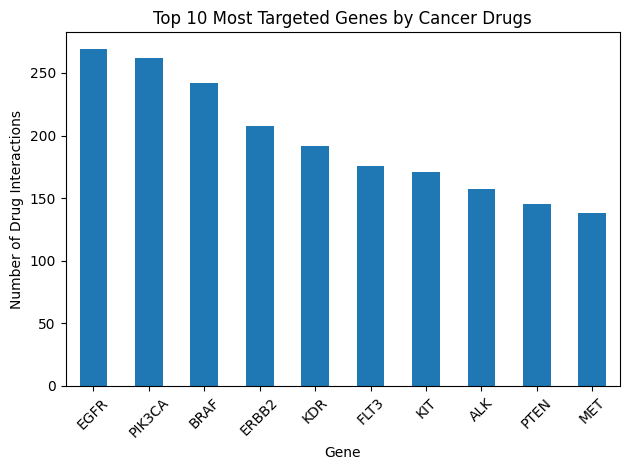

In [7]:
# Create bar chart for the top 10 targeted genes
top_genes.plot(kind="bar")
plt.title("Top 10 Most Targeted Genes by Cancer Drugs")
plt.xlabel("Gene")
plt.ylabel("Number of Drug Interactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Section 7: Fliter CYP450 Genes for Enzymes for Figure 2

In [12]:
# Filter for enzymes represented by CYP450 genes
cyp_df = cancer_df[cancer_df["gene_name"].str.contains("CYP", na=False)].copy()

# Standardize gene names
cyp_df["gene_name"] = cyp_df["gene_name"].str.upper()

# View the filtered data
cyp_df.head()

,gene_claim_name,gene_concept_id,gene_name,interaction_source_db_name,interaction_source_db_version,interaction_type,interaction_score,drug_claim_name,drug_concept_id,drug_name,approved,immunotherapy,anti_neoplastic
843,CYP2A6,hgnc:2610,CYP2A6,PharmGKB,4/5/24,NaN,0.240677,fluorouracil,rxcui:4492,FLUOROURACIL,True,False,True
886,CYP3A5,hgnc:2638,CYP3A5,PharmGKB,4/5/24,NaN,0.017415,celecoxib,rxcui:140587,CELECOXIB,True,False,True
2048,CYP1A2,hgnc:2596,CYP1A2,DTC,9/2/20,NaN,0.016099,CARMUSTINE,rxcui:2105,CARMUSTINE,True,False,True
2256,CYP2C19,hgnc:2621,CYP2C19,DTC,9/2/20,NaN,0.004339,DOXORUBICIN,rxcui:142433,DOXORUBICIN HYDROCHLORIDE,True,False,True
2274,CYP1A2,hgnc:2596,CYP1A2,DTC,9/2/20,NaN,0.012649,ETIDRONIC ACID,rxcui:1356715,ETIDRONIC ACID,True,False,True


Section 8: Count the CYP450 Gene Enzyme Interactions

In [10]:
# Count interactions for CYP450 Enzyme Interactions
cyp_counts = cyp_df["gene_name"].value_counts()

#Display the counts to ensure that it works
cyp_counts

,count
gene_name,
CYP3A4,70
CYP1A2,41
CYP2D6,39
CYP2C9,34
CYP2C19,33
CYP19A1,31
CYP3A5,15
CYP17A1,12
CYP1A1,9


Section 9: Plot CYP450 Gene-Enzymes Interactions

## Figure 2: CYP450 Enzyme Interactions

This figure filters for CYP450 genes and displays how many cancer drugs interact with each enzyme.

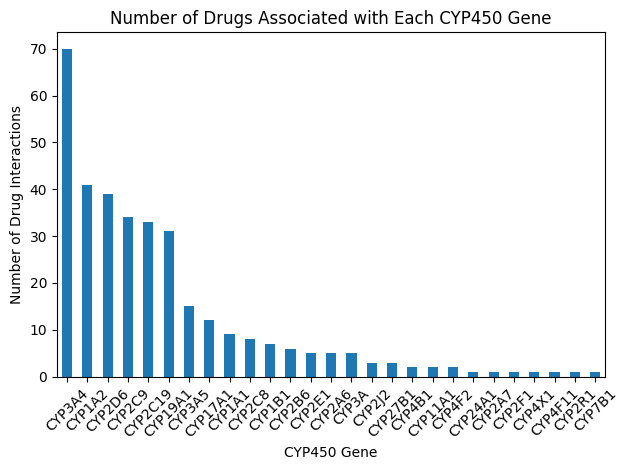

In [11]:
cyp_counts.plot(kind="bar")
plt.title("Number of Drugs Associated with Each CYP450 Gene")
plt.xlabel("CYP450 Gene")
plt.ylabel("Number of Drug Interactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Section 10: Create Table for CYP450 Drug Intercations

##Table 3: CYP450 Enzymes and Associated Cancer Drugs
This table groups CYP450 enzymes with examples of cancer drugs that interact with each enzyme. To improve readability, only up to five drugs are shown for each enzyme.

In [13]:
# Create table with top 5 drugs per CYP450 gene
figure3_table = (
    cyp_df.groupby("gene_name")["drug_name"]
    .apply(lambda x: ", ".join(sorted(x.unique())[:5]))
    .reindex(cyp_counts.index)
    .reset_index()
)

figure3_table.columns = ["CYP450 Gene", "Top 5 Associated Drugs"]

# Display table
figure3_table.head(27)

,CYP450 Gene,Top 5 Associated Drugs
0,CYP3A4,"ALECTINIB, AMSACRINE, ASPIRIN, AZATHIOPRINE, C..."
1,CYP1A2,"AMSACRINE, ASPIRIN, AZATHIOPRINE, CAMPTOTHECIN..."
2,CYP2D6,"AMSACRINE, ASPIRIN, AZATHIOPRINE, CARMUSTINE, ..."
3,CYP2C9,"AMSACRINE, ASPIRIN, AZATHIOPRINE, CARMUSTINE, ..."
4,CYP2C19,"AMSACRINE, ASPIRIN, AZATHIOPRINE, BOSUTINIB, C..."
5,CYP19A1,"ALENDRONATE SODIUM, AMINOGLUTETHIMIDE, ANASTRO..."
6,CYP3A5,"CABAZITAXEL, CARBOPLATIN, CELECOXIB, ERLOTINIB..."
7,CYP17A1,"ABIRATERONE ACETATE, ENZALUTAMIDE, ORTERONEL"
8,CYP1A1,"CAPECITABINE, DACARBAZINE, DAUNORUBICIN LIPOSO..."
9,CYP2C8,"CABAZITAXEL, FLUOROURACIL, GEMCITABINE, IBUPRO..."
